# Chest X-Ray Pneumonia Classification
### VGG19 Transfer Learning + Custom CNN Baseline

This notebook trains two models to classify chest X-rays as **NORMAL** or **PNEUMONIA**:
1. A transfer-learning model built on **VGG19** (pretrained on ImageNet)
2. A **custom CNN** trained from scratch, for comparison

**Dataset split:** 100/100 train, 30/30 validation, 45/45 test images (balanced, 2 classes).

> Fixed vs. the original version: consistent `tensorflow.keras` imports, proper VGG19
> preprocessing, correct layer freezing, non-shuffled test generator (so metrics line
> up with labels), data augmentation, callbacks, a fixed custom-CNN head, model saving,
> and extra evaluation visuals (ROC curve, misclassified examples, Grad-CAM).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, auc)

# reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: []


## 1. Mount Data (Colab) / Set Paths

If running on Google Colab, mount your drive. Otherwise just set `DATA_DIR` to wherever
you've unzipped the `chest_x_ray` dataset locally (e.g. after cloning this repo and
downloading the data separately — see the README for why the dataset itself isn't
committed to git).


In [5]:
IN_COLAB = "google.colab" in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/chest_x_ray"
else:
    DATA_DIR = "./data/chest_x_ray"

TRAIN_DIR = f"{DATA_DIR}/traindata"
VAL_DIR   = f"{DATA_DIR}/validationdata"
TEST_DIR  = f"{DATA_DIR}/testdata"
IMG_SIZE  = (224, 224)
BATCH_SIZE = 16   # small dataset -> smaller batch size trains more stably

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data Generators

Key fixes from the original:
- **`preprocessing_function=preprocess_input`** — VGG19 was trained on ImageNet with a
  specific mean-subtraction/BGR preprocessing. Feeding it raw 0–255 pixels (as the
  original notebook did) hurts accuracy badly.
- **Augmentation on the training set only** (flips, small rotation/zoom) — with just
  100 images/class this is important to reduce overfitting. Never augment val/test data.
- **`shuffle=False` on the test generator** — this is the critical fix. With shuffling
  on, `testdata.classes` (the true labels, in on-disk order) no longer lines up with
  the order `predict()` produces, which silently corrupts your confusion matrix and
  classification report.


In [8]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

traindata = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=42,
)
validationdata = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=42,
)
testdata = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,   # <-- required for correct evaluation
)

print("Class indices:", traindata.class_indices)

Found 200 images belonging to 2 classes.
Found 60 images belonging to 2 classes.
Found 90 images belonging to 2 classes.
Class indices: {'normal': 0, 'pneumonia': 1}


## 3. Visualization — Class Balance & Sample Images

Before training, always look at your data: check the classes are balanced, and eyeball
a few images to sanity-check labels and preprocessing.


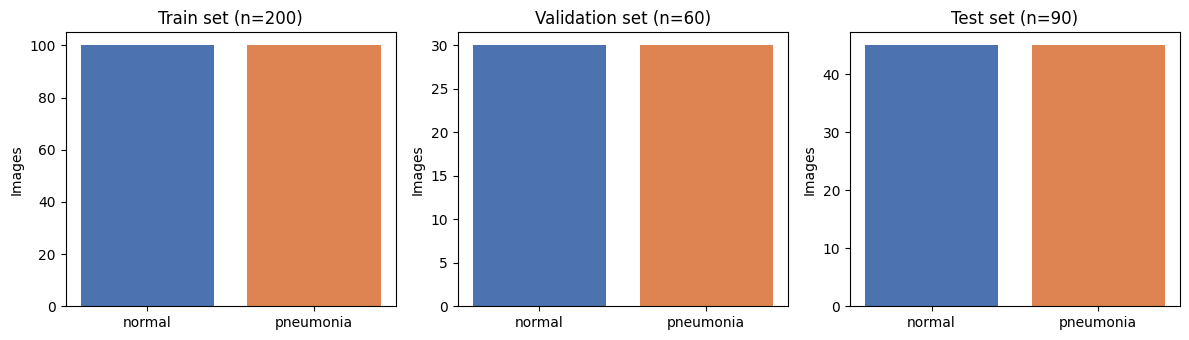

In [10]:
import os

# Create the outputs directory if it doesn't exist
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
for i, (name, gen) in enumerate([("Train", traindata), ("Validation", validationdata), ("Test", testdata)]):
    counts = np.bincount(gen.classes)
    ax[i].bar(gen.class_indices.keys(), counts, color=["#4C72B0", "#DD8452"])
    ax[i].set_title(f"{name} set (n={len(gen.classes)})")
    ax[i].set_ylabel("Images")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "class_balance.png"), dpi=120)
plt.show()

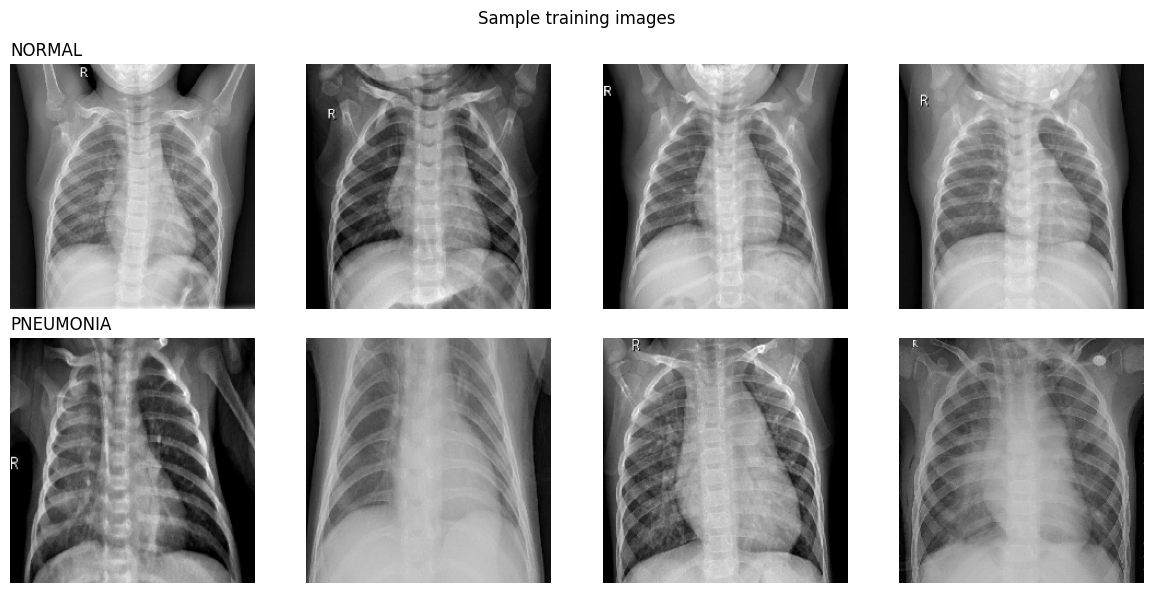

In [11]:
# Sample a few raw images (before preprocessing) from each class
sample_dir_normal = os.path.join(TRAIN_DIR, "normal")
sample_dir_pneu = os.path.join(TRAIN_DIR, "pneumonia")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row, (label, folder) in enumerate([("NORMAL", sample_dir_normal), ("PNEUMONIA", sample_dir_pneu)]):
    files = sorted(os.listdir(folder))[:4]
    for col, fname in enumerate(files):
        img = tf.keras.preprocessing.image.load_img(os.path.join(folder, fname), target_size=IMG_SIZE)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(label)
    axes[row, 0].set_title(label, loc="left")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.savefig("outputs/sample_images.png", dpi=120)
plt.show()


## 4. VGG19 Transfer Learning Model

- Load VGG19 with `include_top=False` (we don't want ImageNet's 1000-class head).
- Freeze the entire convolutional base — this is the "transfer" part: reuse the
  general-purpose visual features VGG19 already learned, without destroying them
  on our tiny 200-image training set.
- Add a small custom classification head on top.
- `GlobalAveragePooling2D` is used instead of `Flatten` — it produces far fewer
  parameters, which matters a lot when you only have 100 images per class
  (Flatten + Dense here would create tens of millions of extra parameters that would
  overfit almost immediately).


In [12]:
base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the whole pretrained base
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
predictions = Dense(2, activation="softmax")(x)

model_final = Model(inputs=base_model.input, outputs=predictions)
model_final.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,226 (76.89 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

## 5. Compile & Callbacks

In [13]:
optimizer = optimizers.Adam(learning_rate=1e-4)  # lower LR: only the head is training
model_final.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("models/vgg19_best.keras", monitor="val_accuracy", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]


## 6. Train

In [14]:
history = model_final.fit(
    traindata,
    epochs=30,
    verbose=1,
    validation_data=validationdata,
    callbacks=callbacks,
)


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 283s 22s/step - accuracy: 0.5250 - loss: 2.4871 - val_accuracy: 0.5500 - val_loss: 0.8959 - learning_rate: 1.0000e-04
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 245s 19s/step - accuracy: 0.6650 - loss: 1.4033 - val_accuracy: 0.7333 - val_loss: 0.6541 - learning_rate: 1.0000e-04
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 208s 16s/step - accuracy: 0.6950 - loss: 1.2820 - val_accuracy: 0.8000 - val_loss: 0.5689 - learning_rate: 1.0000e-04
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 242s 20s/step - accuracy: 0.7550 - loss: 0.8485 - val_accuracy: 0.8667 - val_loss: 0.5996 - learning_rate: 1.0000e-04
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 208s 16s/step - accuracy: 0.7800 - loss: 0.8404 - val_accuracy: 0.8833 - val_loss: 0.3756 - learning_rate: 1.0000e-04
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 207s 16s/step - accuracy: 0.7550 - loss: 0.9072 - val_accuracy: 0.8667 - val_loss: 0.4188 - learning_rate: 1.0000e-04
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 209s 16s/step - accuracy: 

## 7. Visualization — Training Curves

Accuracy and loss curves for train vs. validation, on separate subplots. Watch for the
validation loss curve turning upward while training loss keeps falling — that's
overfitting, and with only 200 training images it's the main risk here.


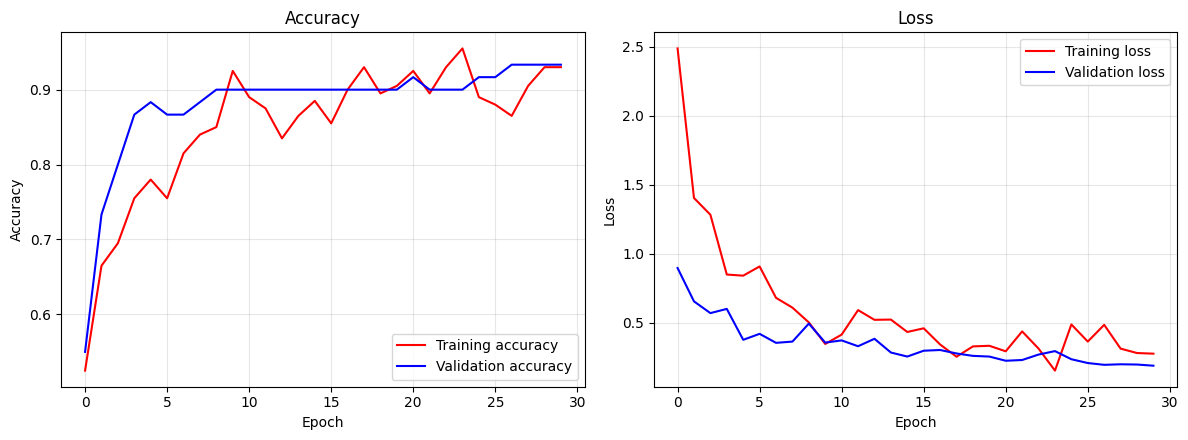

In [15]:
acc, val_acc = history.history["accuracy"], history.history["val_accuracy"]
loss, val_loss = history.history["loss"], history.history["val_loss"]
epochs_range = range(len(acc))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(epochs_range, acc, "r", label="Training accuracy")
ax[0].plot(epochs_range, val_acc, "b", label="Validation accuracy")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Accuracy")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(epochs_range, loss, "r", label="Training loss")
ax[1].plot(epochs_range, val_loss, "b", label="Validation loss")
ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss")
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/vgg19_training_curves.png", dpi=120)
plt.show()


## 8. Evaluate on Test Set

With `shuffle=False` on `testdata`, `testdata.classes` now correctly lines up with
`predict()`'s output order, so the confusion matrix and report are trustworthy.


=========== VGG19 — TEST RESULTS ===========
6/6 ━━━━━━━━━━━━━━━━━━━━ 72s 12s/step
              precision    recall  f1-score   support

      normal       0.92      0.98      0.95        45
   pneumonia       0.98      0.91      0.94        45

    accuracy                           0.94        90
   macro avg       0.95      0.94      0.94        90
weighted avg       0.95      0.94      0.94        90



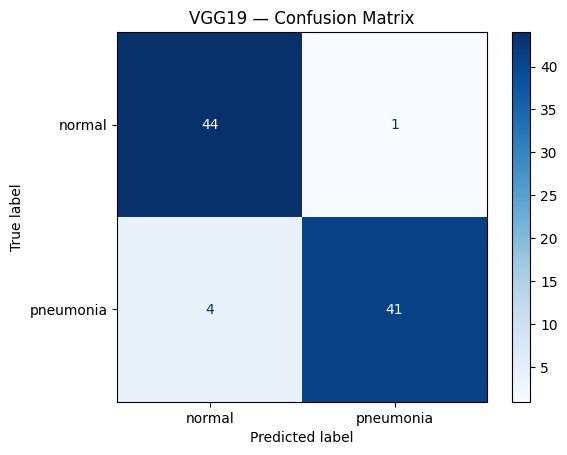

In [16]:
print("=========== VGG19 — TEST RESULTS ===========")
Y_pred = model_final.predict(testdata)
y_pred = np.argmax(Y_pred, axis=1)
y_true = testdata.classes
target_names = list(testdata.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=target_names)
cmd.plot(cmap="Blues")
plt.title("VGG19 — Confusion Matrix")
plt.savefig("outputs/vgg19_confusion_matrix.png", dpi=120)
plt.show()


### ROC Curve & AUC

For a binary medical classifier, the ROC/AUC is often more informative than accuracy
alone — it shows the sensitivity/specificity trade-off as the decision threshold
changes, which matters clinically (missing a pneumonia case is worse than a false
alarm).


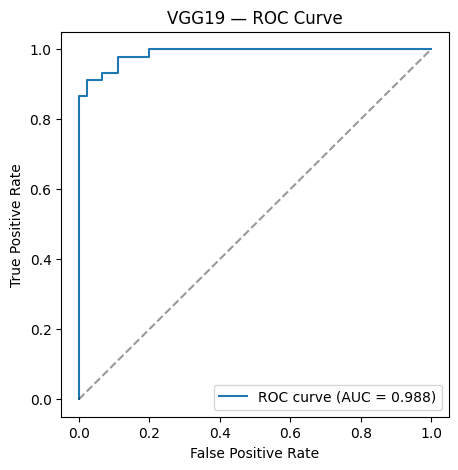

In [17]:
fpr, tpr, _ = roc_curve(y_true, Y_pred[:, 1])  # class index 1 = PNEUMONIA (check class_indices)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("VGG19 — ROC Curve"); plt.legend(loc="lower right")
plt.savefig("outputs/vgg19_roc_curve.png", dpi=120)
plt.show()


### Misclassified Examples

Looking at the actual images the model got wrong is one of the most useful diagnostic
visuals for a medical-imaging model — it often reveals whether errors are random or
systematic (e.g. always confusing borderline/early-stage cases).


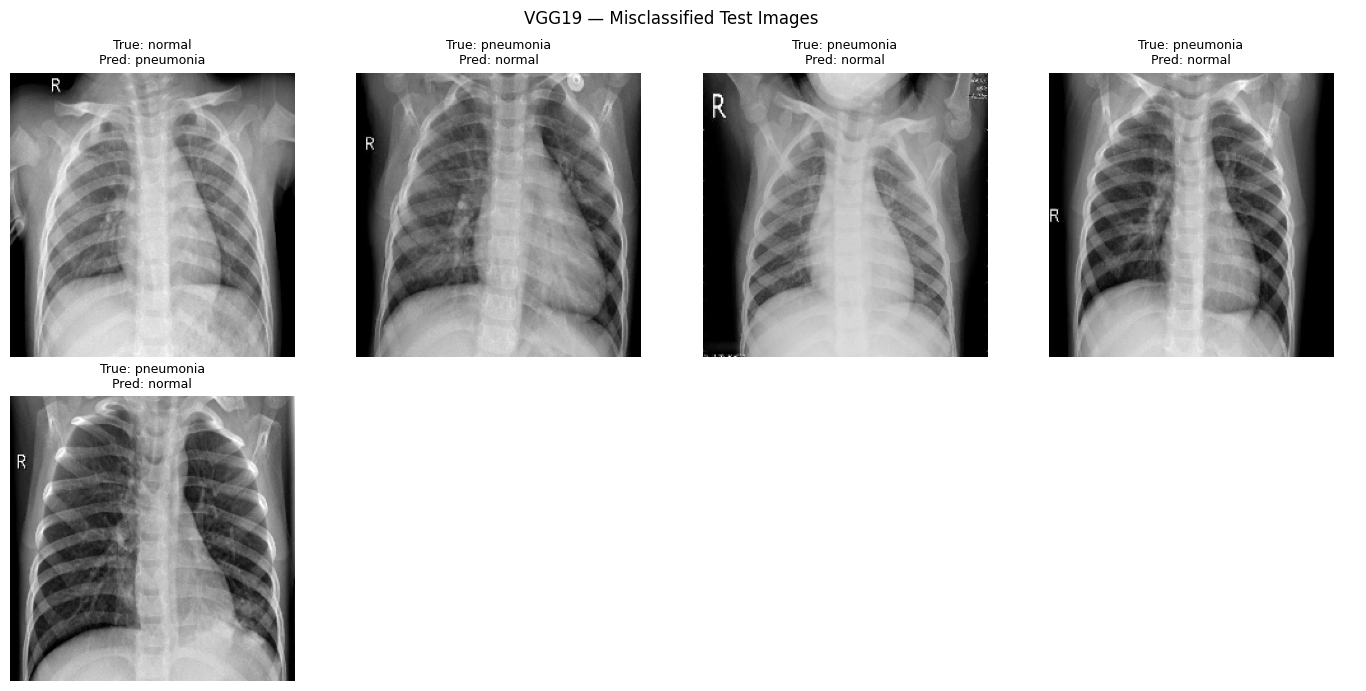

In [18]:
wrong_idx = np.where(y_pred != y_true)[0][:8]
filepaths = np.array(testdata.filepaths)

if len(wrong_idx) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, idx in zip(axes.flatten(), wrong_idx):
        img = tf.keras.preprocessing.image.load_img(filepaths[idx], target_size=IMG_SIZE)
        ax.imshow(img)
        ax.set_title(f"True: {target_names[y_true[idx]]}\nPred: {target_names[y_pred[idx]]}", fontsize=9)
        ax.axis("off")
    for ax in axes.flatten()[len(wrong_idx):]:
        ax.axis("off")
    plt.suptitle("VGG19 — Misclassified Test Images")
    plt.tight_layout()
    plt.savefig("outputs/vgg19_misclassified.png", dpi=120)
    plt.show()
else:
    print("No misclassifications on the test set.")


## 9. Custom CNN (Trained From Scratch) — Baseline for Comparison

This is a fixed version of your custom architecture. Two bugs are corrected:
- The original squeezed down to a **2-unit ReLU Dense layer right before the softmax
  output** — that's an extreme information bottleneck that throws away almost
  everything the convolutional layers learned. Replaced with a proper 512-unit dense
  layer.
- The model was **built but never compiled or trained**. Added compile + fit here so
  it's an actual, comparable baseline against the VGG19 transfer-learning model.

Six conv blocks on a 200-image training set is a lot of capacity for very little data —
expect this model to overfit faster and score lower than VGG19. That contrast is
exactly the point of including it: it demonstrates *why* transfer learning helps here.


In [19]:
custom_model = Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.GlobalAveragePooling2D(),   # fewer params than Flatten on this small dataset
    tf.keras.layers.Dense(512, activation="relu"),   # fixed: was Dense(2, relu) - a bottleneck
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(2, activation="softmax"),
])
custom_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,594 (1.38 MB)

 Trainable params: 360,594 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
custom_model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

custom_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("models/custom_cnn_best.keras", monitor="val_accuracy", save_best_only=True),
]

custom_history = custom_model.fit(
    traindata,
    epochs=30,
    verbose=1,
    validation_data=validationdata,
    callbacks=custom_callbacks,
)


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.4950 - loss: 0.7239 - val_accuracy: 0.5000 - val_loss: 0.6838
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5700 - loss: 0.6879 - val_accuracy: 0.5000 - val_loss: 0.6727
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5500 - loss: 0.6863 - val_accuracy: 0.5000 - val_loss: 0.6954
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5050 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.5850 - loss: 0.6829 - val_accuracy: 0.5000 - val_loss: 0.6803
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4800 - loss: 0.6916 - val_accuracy: 0.7333 - val_loss: 0.6789
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.5850 - loss: 0.6862 - val_accuracy: 0.5000 - val_loss: 0.6678
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5800 - loss: 0.6714 - val_accuracy: 0.6000 - val_loss:

=========== CUSTOM CNN — TEST RESULTS ===========
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 626ms/step
              precision    recall  f1-score   support

      normal       0.84      0.80      0.82        45
   pneumonia       0.81      0.84      0.83        45

    accuracy                           0.82        90
   macro avg       0.82      0.82      0.82        90
weighted avg       0.82      0.82      0.82        90



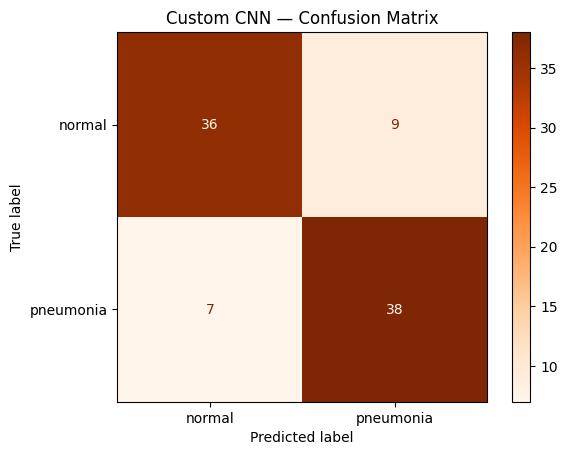

In [21]:
print("=========== CUSTOM CNN — TEST RESULTS ===========")
testdata.reset()
Y_pred_c = custom_model.predict(testdata)
y_pred_c = np.argmax(Y_pred_c, axis=1)

print(classification_report(y_true, y_pred_c, target_names=target_names))

cm_c = confusion_matrix(y_true, y_pred_c)
ConfusionMatrixDisplay(cm_c, display_labels=target_names).plot(cmap="Oranges")
plt.title("Custom CNN — Confusion Matrix")
plt.savefig("outputs/custom_cnn_confusion_matrix.png", dpi=120)
plt.show()


## 10. Model Comparison Visualization

A side-by-side comparison is the clearest way to show *why* transfer learning was the
right call on a small medical-imaging dataset like this one.


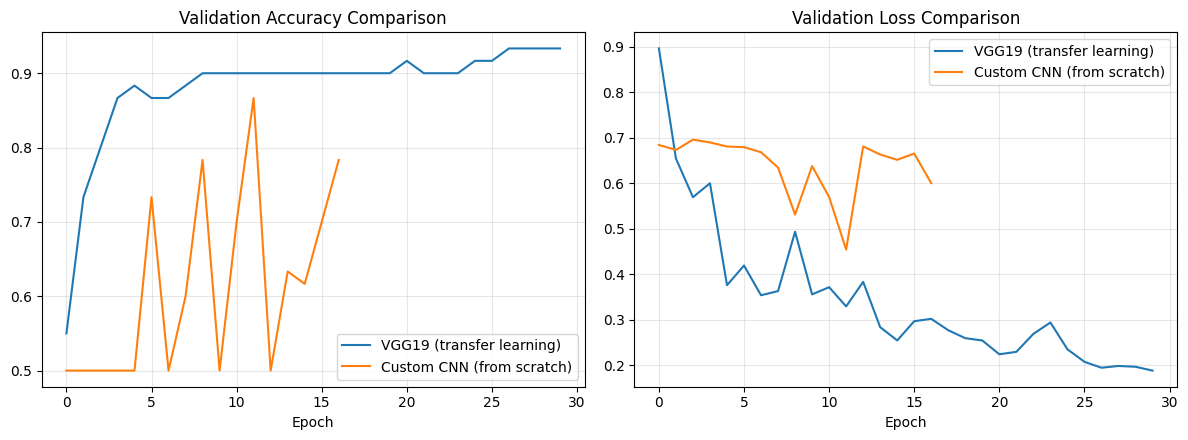

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(history.history["val_accuracy"], label="VGG19 (transfer learning)")
ax[0].plot(custom_history.history["val_accuracy"], label="Custom CNN (from scratch)")
ax[0].set_title("Validation Accuracy Comparison"); ax[0].set_xlabel("Epoch")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(history.history["val_loss"], label="VGG19 (transfer learning)")
ax[1].plot(custom_history.history["val_loss"], label="Custom CNN (from scratch)")
ax[1].set_title("Validation Loss Comparison"); ax[1].set_xlabel("Epoch")
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=120)
plt.show()


## 11. Grad-CAM — Where Is the Model Looking?

For a medical-imaging model, showing *what the model is basing its decision on* is one
of the most valuable visualizations you can add — it's a basic interpretability check
that helps confirm the model is looking at lung fields rather than, say, text markers
or borders in the image.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


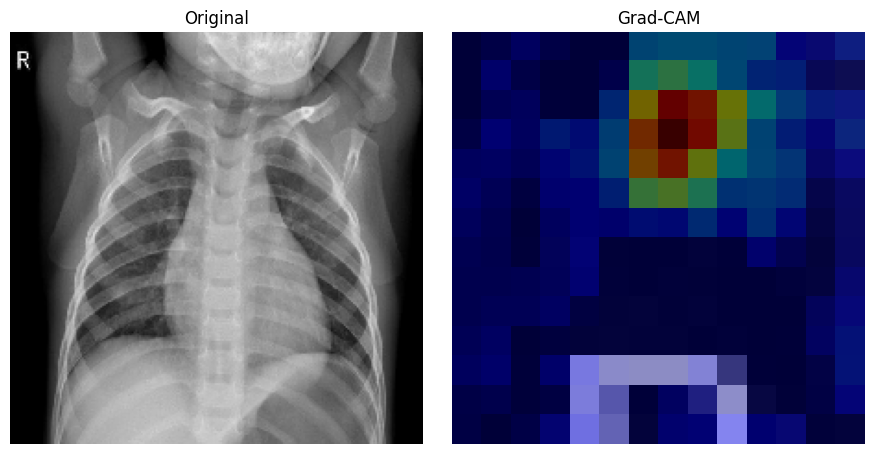

In [23]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# find VGG19's last conv layer name
last_conv_name = [l.name for l in base_model.layers if "conv" in l.name][-1]

sample_path = filepaths[0]
img = tf.keras.preprocessing.image.load_img(sample_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = preprocess_input(np.expand_dims(img_array, axis=0))

heatmap = make_gradcam_heatmap(img_array, model_final, last_conv_name)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(img); ax[1].imshow(heatmap, cmap="jet", alpha=0.45); ax[1].set_title("Grad-CAM"); ax[1].axis("off")
plt.tight_layout()
plt.savefig("outputs/gradcam_example.png", dpi=120)
plt.show()


## 12. Save Final Models

`ModelCheckpoint` already saved the best-epoch weights during training
(`models/vgg19_best.keras`, `models/custom_cnn_best.keras`). This also saves the final
in-memory models explicitly.


In [24]:
model_final.save("models/vgg19_final.keras")
custom_model.save("models/custom_cnn_final.keras")
print("Models saved to ./models/")


Models saved to ./models/
